In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.671913,-0.360019,-3.735553,-0.526296,1.595551,1
1,0.679707,0.685944,-1.127885,-2.969478,-2.557180,0
2,1.947622,1.969924,-0.467931,-1.582932,-1.671761,0
3,1.750515,1.822656,-0.430455,-0.805412,-1.554798,0
4,-1.163204,-2.592781,-0.156909,-0.882653,-1.306140,1


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
  cols = df.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = sample_rows(df,0.2)

In [8]:
df2 = sample_rows(df,0.2)

In [9]:
df3 = sample_rows(df,0.2)

In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [11]:
df3

,col1,col2,col3,col4,col5,target
93,0.016039,0.271906,-0.604478,-2.464489,-3.494313,0
76,-0.931785,-1.258258,0.408973,-2.061656,0.620818,1
89,-0.997559,0.816783,-2.450593,-1.917444,3.426611,1
31,1.458713,1.339188,-1.578569,0.344085,-3.465478,0
28,2.117271,1.667984,-1.371039,-2.395278,-3.720673,0
90,0.514588,0.235680,-1.053498,-1.687955,0.944262,0
25,0.195300,0.592371,0.115650,-1.342491,0.836898,0
81,0.647275,0.830229,-1.139839,-2.657328,0.005457,0
83,-0.286576,-1.010339,-2.318284,-2.081370,0.740188,0
1,0.679707,0.685944,-1.127885,-2.969478,-2.557180,0


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [14]:
from sklearn.tree import plot_tree

[Text(0.5555555555555556, 0.875, 'x[0] <= -0.43\ngini = 0.42\nsamples = 20\nvalue = [14, 6]'),
 Text(0.3333333333333333, 0.625, 'x[3] <= -1.727\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[3] <= -2.767\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.1111111111111111, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4444444444444444, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.7777777777777778, 0.625, 'x[4] <= 1.328\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.8888888888888888, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

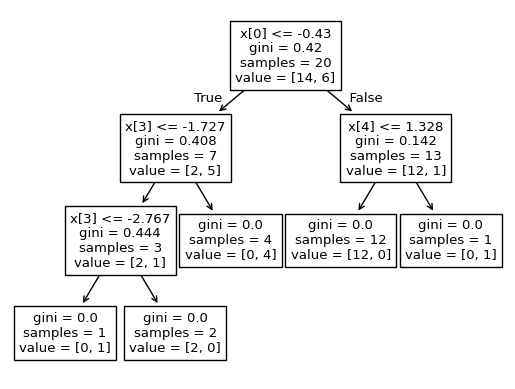

In [15]:
plot_tree(clf1)

[Text(0.5555555555555556, 0.875, 'x[1] <= 0.476\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.3333333333333333, 0.625, 'x[1] <= -2.601\ngini = 0.245\nsamples = 14\nvalue = [2, 12]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[4] <= 0.566\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.1111111111111111, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4444444444444444, 0.375, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.7777777777777778, 0.625, 'x[4] <= 1.58\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.8888888888888888, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

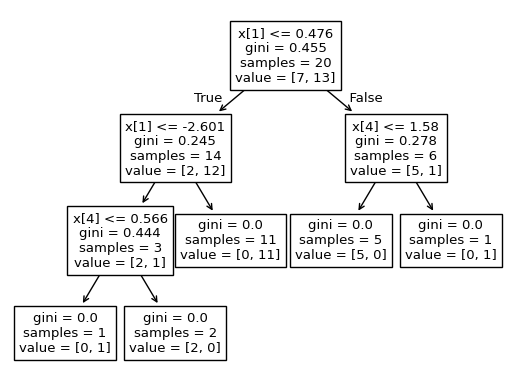

In [16]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[0] <= -0.754\ngini = 0.32\nsamples = 20\nvalue = [16, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.625, 0.5, '  False')]

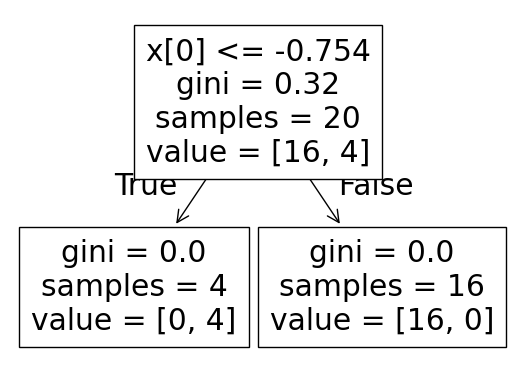

In [17]:
plot_tree(clf3)

In [19]:
clf1.predict(np.array([-0.997559,0.816783,	-2.450593,	-1.917444,	3.426611]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [21]:
clf2.predict(np.array([-0.997559,0.816783,	-2.450593,	-1.917444,	3.426611]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [22]:
clf3.predict(np.array([-0.997559,0.816783,	-2.450593,	-1.917444,	3.426611]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
df.sample(14,replace=True)

,humidity,wind,play
0,0,1,0
0,0,1,0
0,0,1,0
10,1,0,1
13,0,0,0
4,1,1,1
7,0,1,0
6,1,0,1
4,1,1,1
3,0,1,1
